## 데이터 측정 기간 : 2016 ~ 2018
## 데이터 비교 데이터 : 없음



1. 현재 해당 서비스를 사용하고 있는 고객은 얼마나 있는가?
- 96096명

2. 고객은 주로 어디에서 거주하고 있는가?
- sao paulo / rio de janeiro / belo horizonte
  
3. 고객은 주로 어떤 결제 방법을 사용하고 있는가?
- credit_card

------------------------------------------------------------

4. 월별 고객들의 평균 결제액?
- 768,619원 (2017년 11월 최고매출 달성 월)

5. 일, 주, 월별 판매 트랜드
- 

6. 어떤 카테고리가 가장 많은 상품이 판매되었을까?
- 

In [3]:
import pandas as pd

PATH = "00_data"

In [4]:
products = pd.read_csv(f"{PATH}/olist_products_dataset.csv", encoding="utf-8-sig")
customers = pd.read_csv(f"{PATH}/olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}/olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}/olist_order_items_dataset.csv", encoding="utf-8-sig") 
payments = pd.read_csv(f"{PATH}/olist_order_payments_dataset.csv", encoding="utf-8-sig") 
reviews = pd.read_csv(f"{PATH}/olist_order_reviews_dataset.csv", encoding="utf-8-sig") 
orders = pd.read_csv(f"{PATH}/olist_orders_dataset.csv", encoding="utf-8-sig") 
sellers = pd.read_csv(f"{PATH}/olist_sellers_dataset.csv", encoding="utf-8-sig") 
category_name = pd.read_csv(f"{PATH}/product_category_name_translation.csv", encoding="utf-8-sig") 

In [5]:
payments.head() # payment_value 쿠폰같은거 적용한 금액

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [5]:
order_items.head() # price, freight_value 순수한 상품가격과 배송비

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.shape

(99441, 8)

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [10]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [11]:
orders = orders.dropna()

In [12]:
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [13]:
orders.info() # 99441 -> 96461 결측치 제거 후 값이 변함

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [14]:
payments.shape

(103886, 5)

In [15]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [16]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

# 서로 다른 데이터프레임을 병합하고자 할 때 순서

1. 각 데이터프레임 내 결측치 값이 존재를 확인하고 제거한다
2. 데이터프레임을 연결할 수 있는 FK기 확인 -> order_id
3. FK가 각 데이터프레임 내 중복값을 가지고 있는지, 고유한 값이지 확인 -> 고유값이라고 확인 되면 그 때 병합

In [18]:
orders["order_id"].value_counts().max()

1

In [19]:
payments["order_id"].value_counts() # 중복사용되었음을 확인

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
                                    ..
4b186efcda6f283e9c4a71332f6d3ad0     1
c11717d999ffc510a6441df946f0a94d     1
f593228a7a25e9633ff78a4ce0d0d4cc     1
387c2c33e495538e94878a500bf8e6d5     1
d5639d8a973cec351be75a3186835068     1
Name: count, Length: 99440, dtype: int64

In [20]:
payments = payments.groupby("order_id").sum()

In [25]:
payments = payments.reset_index()

In [26]:
payments["order_id"].value_counts().max()

1

In [27]:
payments.shape

(99440, 5)

In [29]:
import pandas as pd

merged_order = pd.merge(orders, payments, on="order_id", how="left")

In [30]:
merged_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,6.0,credit_cardvouchervoucher,3.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,credit_card,1.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,credit_card,1.0,28.62


In [31]:
merged_order.shape

(96461, 12)

In [32]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96461 entries, 0 to 96460
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96461 non-null  object 
 1   customer_id                    96461 non-null  object 
 2   order_status                   96461 non-null  object 
 3   order_purchase_timestamp       96461 non-null  object 
 4   order_approved_at              96461 non-null  object 
 5   order_delivered_carrier_date   96461 non-null  object 
 6   order_delivered_customer_date  96461 non-null  object 
 7   order_estimated_delivery_date  96461 non-null  object 
 8   payment_sequential             96460 non-null  float64
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  float64
 11  payment_value                  96460 non-null  float64
dtypes: float64(3), object(9)
memory usage: 8.8+ MB

In [33]:
merged_order = merged_order.dropna()

In [34]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96460 entries, 0 to 96460
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96460 non-null  object 
 1   customer_id                    96460 non-null  object 
 2   order_status                   96460 non-null  object 
 3   order_purchase_timestamp       96460 non-null  object 
 4   order_approved_at              96460 non-null  object 
 5   order_delivered_carrier_date   96460 non-null  object 
 6   order_delivered_customer_date  96460 non-null  object 
 7   order_estimated_delivery_date  96460 non-null  object 
 8   payment_sequential             96460 non-null  float64
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  float64
 11  payment_value                  96460 non-null  float64
dtypes: float64(3), object(9)
memory usage: 9.6+ MB


In [35]:
merged_order.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
dtype: int64

In [37]:
merged_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,6.0,credit_cardvouchervoucher,3.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,credit_card,1.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,credit_card,1.0,28.62


In [38]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96460 entries, 0 to 96460
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96460 non-null  object 
 1   customer_id                    96460 non-null  object 
 2   order_status                   96460 non-null  object 
 3   order_purchase_timestamp       96460 non-null  object 
 4   order_approved_at              96460 non-null  object 
 5   order_delivered_carrier_date   96460 non-null  object 
 6   order_delivered_customer_date  96460 non-null  object 
 7   order_estimated_delivery_date  96460 non-null  object 
 8   payment_sequential             96460 non-null  float64
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  float64
 11  payment_value                  96460 non-null  float64
dtypes: float64(3), object(9)
memory usage: 9.6+ MB


In [40]:
# 날짜에 따른 결제금약을 시계열차트로 정렬해서 시각화를 하려고 하는데
# 그러려면 해당 데이터의 타입이 문자가 아니라 날짜 타입이 되어야한다
# 현재 오브젝트(문자)이기 때문에 날짜 타입으로 변경하고자 함

import pandas as pd

df = pd.DataFrame({
    "order": [
        "2020-01-01 01:10:00",
        "2020-01-08 07:20:00",
        "2020-02-20 11:20:00",
        "2020-02-20 04:40:00",
        "2020-02-28 12:10:20",
        "2020-01-10 17:23:50",
        "2020-06-20 22:27:50",
        "2020-06-20 21:15:59",
        "2020-12-10 21:27:59"
    ]
})

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   order   9 non-null      object
dtypes: object(1)
memory usage: 204.0+ bytes


In [45]:
import pandas as pd

df["order"] = pd.to_datetime(df["order"], format="%Y-%m-%d %H:%M:%S", errors="raise") 

### to_datetime() -> 날짜 옵션목록

1. %y : 연도를 두 글자로 표기
2. %Y : 연도를 네 글자로 표기
3. %m : 월을 두 글자로 표기 (01~12)
4. %d : 일을 두 글자로 표기 (01~31)
5. %H : 시간을 24시간 기준 표기 (00~23)
6. %M : 분을 두 글자로 표기 (00~59)
7. %S : 초를 두 글자로 표기 (00~59)


- errors : 만약 날짜형태로 값을 바꾸기에 불출족한 조건 문자열
- errors=ignore : 무시하고 진행
- errors=raise : 에러를 표기하고 어떤 에러인지 표기
- errors=coerce : 에러를 NaT 형태로 값을 변환하고 진행

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   order   9 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 204.0 bytes


In [9]:
import pandas as pd

# orders.shape
# orders.info()
orders = orders.dropna()

In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [11]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [15]:
#payments
#payments.shape
#payments.info()
payments = payments.groupby("order_id").sum()

In [18]:
# payments.head()
payments = payments.reset_index()

In [19]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,1,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,credit_card,3,218.04
...,...,...,...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,1,boleto,1,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,1,boleto,1,386.53
99437,fffce4705a9662cd70adb13d4a31832d,1,credit_card,3,116.85
99438,fffe18544ffabc95dfada21779c9644f,1,credit_card,3,64.71


In [20]:
import pandas as pd

merged_order = pd.merge(orders, payments, on="order_id")

In [21]:
# 지난시간에 연습했던 문자열 타입의 날짜를 본연의 날짜 타입으로 변경

merged_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,6,credit_cardvouchervoucher,3,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,credit_card,1,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,credit_card,1,28.62


In [22]:
merged_order.shape

(96460, 12)

In [24]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96460 non-null  object 
 1   customer_id                    96460 non-null  object 
 2   order_status                   96460 non-null  object 
 3   order_purchase_timestamp       96460 non-null  object 
 4   order_approved_at              96460 non-null  object 
 5   order_delivered_carrier_date   96460 non-null  object 
 6   order_delivered_customer_date  96460 non-null  object 
 7   order_estimated_delivery_date  96460 non-null  object 
 8   payment_sequential             96460 non-null  int64  
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  int64  
 11  payment_value                  96460 non-null  float64
dtypes: float64(1), int64(2), object(9)
memory usag

In [25]:
merged_order["order_purchase_timestamp"] = pd.to_datetime(merged_order["order_purchase_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")

In [26]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96460 non-null  object        
 1   customer_id                    96460 non-null  object        
 2   order_status                   96460 non-null  object        
 3   order_purchase_timestamp       96460 non-null  datetime64[ns]
 4   order_approved_at              96460 non-null  object        
 5   order_delivered_carrier_date   96460 non-null  object        
 6   order_delivered_customer_date  96460 non-null  object        
 7   order_estimated_delivery_date  96460 non-null  object        
 8   payment_sequential             96460 non-null  int64         
 9   payment_type                   96460 non-null  object        
 10  payment_installments           96460 non-null  int64         
 11  payment_value  

In [27]:
merged_order_payment_date = merged_order[["order_purchase_timestamp", "payment_value"]].copy()

In [28]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,38.71
1,2018-07-24 20:41:37,141.46
2,2018-08-08 08:38:49,179.12
3,2017-11-18 19:28:06,72.20
4,2018-02-13 21:18:39,28.62


In [29]:
merged_order_payment_date = merged_order_payment_date.set_index("order_purchase_timestamp")

In [30]:
merged_order_payment_date

,payment_value
order_purchase_timestamp,
2017-10-02 10:56:33,38.71
2018-07-24 20:41:37,141.46
2018-08-08 08:38:49,179.12
2017-11-18 19:28:06,72.20
2018-02-13 21:18:39,28.62
...,...
2017-03-09 09:54:05,85.08
2018-02-06 12:58:58,195.00
2017-08-27 14:46:43,271.01


In [33]:
merged_order_payment_date = merged_order_payment_date.reset_index()

In [34]:
merged_order_payment_date

,index,order_purchase_timestamp,payment_value
0,0,2017-10-02 10:56:33,38.71
1,1,2018-07-24 20:41:37,141.46
2,2,2018-08-08 08:38:49,179.12
3,3,2017-11-18 19:28:06,72.20
4,4,2018-02-13 21:18:39,28.62
...,...,...,...
96455,96455,2017-03-09 09:54:05,85.08
96456,96456,2018-02-06 12:58:58,195.00
96457,96457,2017-08-27 14:46:43,271.01
96458,96458,2018-01-08 21:28:27,441.16


In [35]:
# pandas 라이브러리 모듈안에 Grouper 기능
# groupby -> 동일한 값을 가지고 있다는 전제하에 그룹핑을 하는 것
# 2026-01-01 ~ 2026-01-31 (그룹)


import pandas as pd

merged_order_month_sum = merged_order_payment_date.groupby(pd.Grouper(key="order_purchase_timestamp", freq="ME")).sum()

In [36]:
merged_order_month_sum

,index,payment_value
order_purchase_timestamp,,
2016-10-31,13285926,47271.20
2016-11-30,0,0.00
2016-12-31,38576,19.62
2017-01-31,36482217,127430.74
2017-02-28,79745050,269458.98
2017-03-31,122022814,414369.39
2017-04-30,111811117,390952.18
2017-05-31,171462434,566872.73
2017-06-30,151846239,490225.60


## Grouper 집계 단위

1. ME : Month(ly) End (frequency)
2. QE : Quarter End (frequency)
3. YE : Year End (frequency)
4. D : Calendar Day (frequency)
5. h : Hourly (frequency)
6. min : Minutely (frequency)
7. s : Secondly (frequency)

In [37]:
import pandas as pd

# 특정 시점 부터 특정 시점까지의 데이터를 집계해서 분석하고자 할 때
# date_range()
pd.date_range(start="2025-01-01", end="2025-12-31")  # 파이썬 리스트 | 문자열 (슬라이스)

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=365, freq='D')

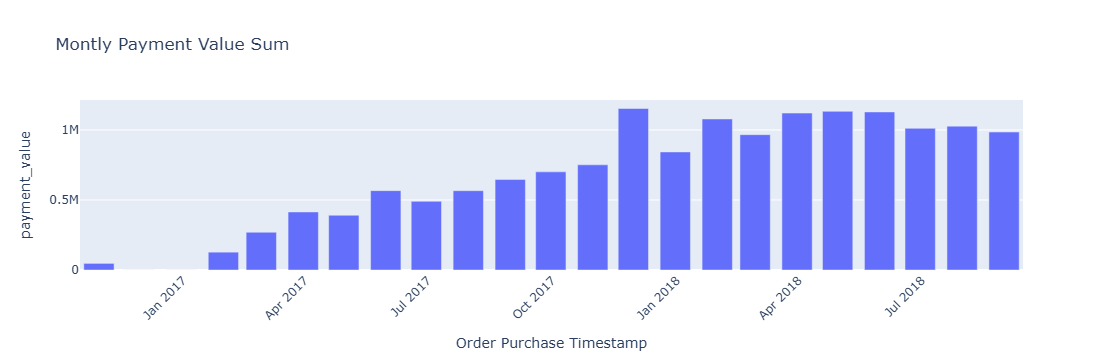

In [42]:
import plotly.express as px

fig = px.bar(
    x = merged_order_month_sum.index,
    y = merged_order_month_sum["payment_value"],
    title = "Montly Payment Value Sum",
    labels={
        "x" : "Order Purchase Timestamp",
        "y" : "payment_value"
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [43]:
merged_order_month_sum["payment_value"].mean()

np.float64(670420.9934782608)

In [44]:
merged_order_month_sum["payment_value"]

order_purchase_timestamp
2016-10-31      47271.20
2016-11-30          0.00
2016-12-31         19.62
2017-01-31     127430.74
2017-02-28     269458.98
2017-03-31     414369.39
2017-04-30     390952.18
2017-05-31     566872.73
2017-06-30     490225.60
2017-07-31     566403.93
2017-08-31     646000.61
2017-09-30     700976.01
2017-10-31     751140.27
2017-11-30    1153393.22
2017-12-31     843199.17
2018-01-31    1078606.86
2018-02-28     966554.97
2018-03-31    1120678.00
2018-04-30    1132933.95
2018-05-31    1128836.69
2018-06-30    1011561.35
2018-07-31    1027383.10
2018-08-31     985414.28
Freq: ME, Name: payment_value, dtype: float64

In [46]:
# 이상치(outlier)를 제외한 값들의 평균치

merged_order_month_sum["payment_value"][3:].mean()

np.float64(768619.6014999999)

In [48]:
# 최대거래액을 기록한 월

merged_order_month_sum[merged_order_month_sum["payment_value"] == merged_order_month_sum["payment_value"].max()]

,index,payment_value
order_purchase_timestamp,,
2017-11-30,347738845,1153393.22
